In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv("data/raw_esg_financial_data.csv")
df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  str    
 2   Industry           11000 non-null  str    
 3   Region             11000 non-null  str    
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(2), str(3)


In [70]:
df.describe()

,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
mean,500.500000,2020.000000,4670.850591,10.900455,13380.622236,4.830370,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07
std,288.688113,3.162421,9969.954369,8.758711,39922.870373,9.424787,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07
min,1.000000,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03
25%,250.750000,2017.000000,938.775000,5.300000,1098.525000,-1.325000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05
50%,500.500000,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06
75%,750.250000,2023.000000,4342.625000,16.300000,9995.500000,11.000000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06
max,1000.000000,2025.000000,180810.400000,50.000000,865271.700000,38.000000,98.800000,100.000000,100.000000,100.000000,1.741047e+08,5.223142e+07,1.741047e+09


In [71]:
#TODO ESG_E7 - Exploratory Data Analysis(EDA)
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

GrowthRate    1000
dtype: int64

In [72]:
#TODO ESG_E7 - Exploratory Data Analysis(EDA)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
esg_cols = [col for col in df.columns if any(x in col.lower() for x in ['esg', 'environment', 'social', 'governance'])]

Q1 = df[esg_cols].quantile(0.25)
Q3 = df[esg_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[esg_cols] < (Q1 - 1.5 * IQR)) | (df[esg_cols] > (Q3 + 1.5 * IQR))).sum()
outliers

ESG_Overall          13
ESG_Environmental     0
ESG_Social            0
ESG_Governance        0
dtype: int64

In [73]:
#TODO ESG_S8 - Univariate-Bivariate Analysis
skew_kurt = pd.DataFrame({
    'Skewness': df[esg_cols].skew(),
    'Kurtosis': df[esg_cols].kurtosis()
})

skew_kurt['Distribution_Type'] = np.where(skew_kurt['Skewness'] > 1, 'Highly Right Skewed',
                                  np.where(skew_kurt['Skewness'] < -1, 'Highly Left Skewed',
                                  'Moderate/Normal'))

skew_kurt

,Skewness,Kurtosis,Distribution_Type
ESG_Overall,-0.044713,-0.346144,Moderate/Normal
ESG_Environmental,0.000174,-1.073793,Moderate/Normal
ESG_Social,-0.000831,-0.858883,Moderate/Normal
ESG_Governance,-0.030436,-1.052276,Moderate/Normal


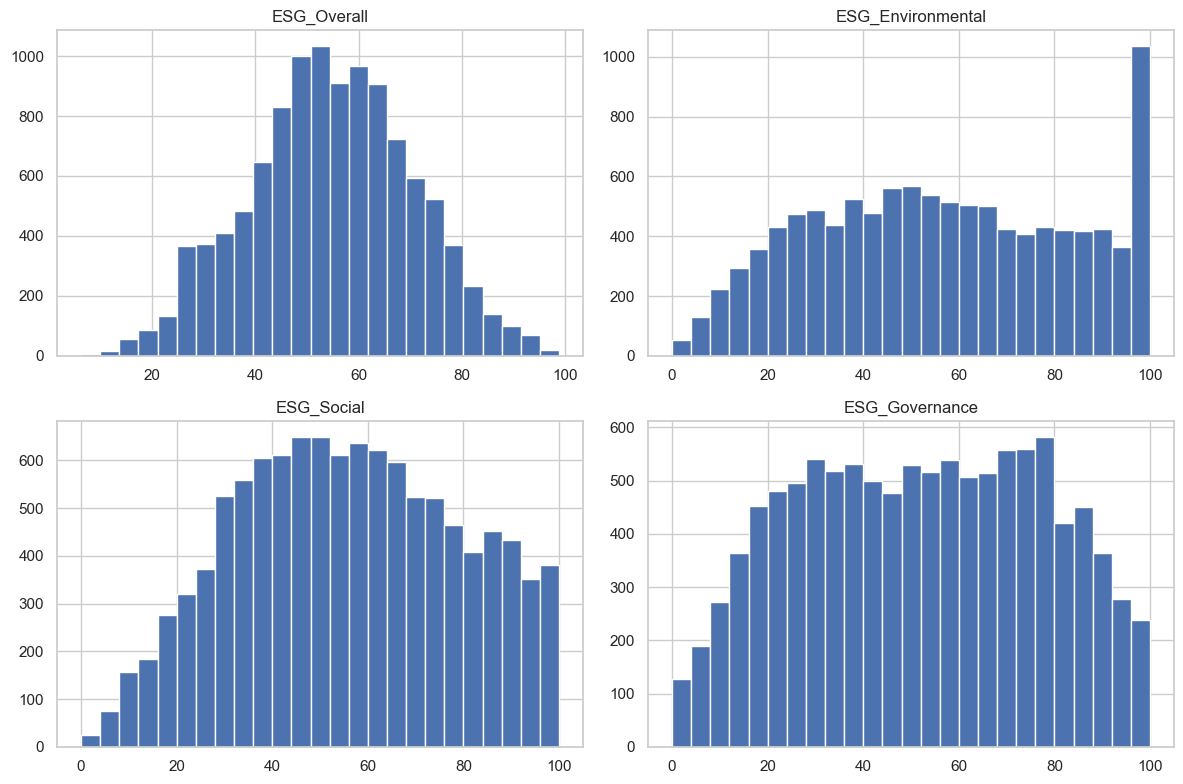

In [74]:
#TODO ESG_T12 - Plot histograms
df[esg_cols].hist(figsize=(12, 8), bins=25)
plt.tight_layout()
plt.show()

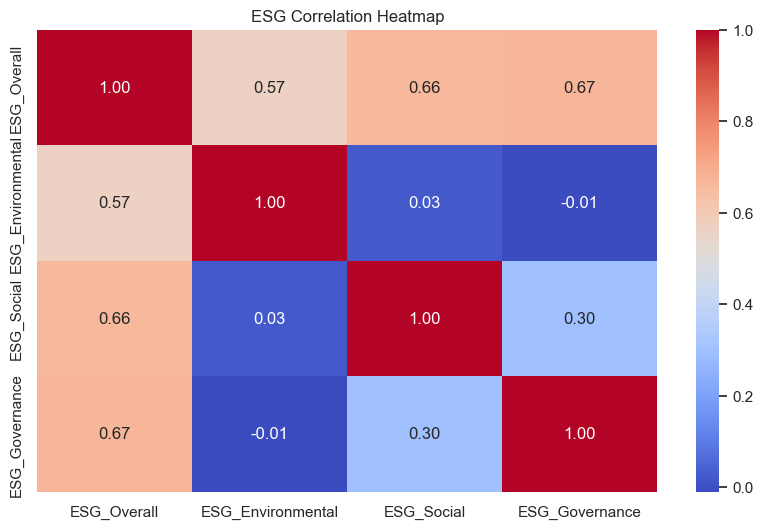

ESG_Overall        ESG_Overall          1.000000
                   ESG_Governance       0.671476
ESG_Social         ESG_Overall          0.662357
ESG_Environmental  ESG_Overall          0.568171
ESG_Governance     ESG_Social           0.298431
ESG_Social         ESG_Environmental    0.025030
ESG_Environmental  ESG_Governance      -0.010290
dtype: float64

In [75]:
#TODO ESG_S8 - Univariate-Bivariate Analysis
corr_matrix = df[esg_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("ESG Correlation Heatmap")
plt.show()

corr_matrix.unstack().sort_values(ascending=False).drop_duplicates().head(10)

In [76]:
#TODO ESG_E8 - Feature Engineering
df_std = df.copy()
df_std[esg_cols] = (df_std[esg_cols] - df_std[esg_cols].mean()) / df_std[esg_cols].std()

df['ESG_Index'] = df_std[esg_cols].mean(axis=1)
df[['ESG_Index']].head()

,ESG_Index
0,0.087436
1,0.075196
2,0.065843
3,0.131847
4,0.064790


In [77]:
#TODO ESG_S9 - Create ESG Index
weights = np.linspace(1, 2, len(esg_cols))
weights = weights / weights.sum()

df['Weighted_ESG_Score'] = df[esg_cols].values.dot(weights)
df[['Weighted_ESG_Score']].head()

,Weighted_ESG_Score
0,57.894444
1,57.816667
2,57.594444
3,58.888889
4,57.288889


In [78]:
#TODO ESG_T13 - Compute ESG score
df[['ESG_Index', 'Weighted_ESG_Score']].corr()

,ESG_Index,Weighted_ESG_Score
ESG_Index,1.000000,0.993756
Weighted_ESG_Score,0.993756,1.000000
